<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Estimation_of_the_Average_Customer_Check_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple linear regression
The online store owner wants to understand which factors influence the average customer check (target variable). To do this, a multiple linear regression model can be built to predict the average customer check based on several explanatory variables.

Data description:
- Target variable (`y`): Average check (USD).

Explanatory variables:
- `x₁`: Number of items in the cart.
- `x₂`: Average price per item (USD).
- `x₃`: Discount percentage applied to the order (%).
- `x₄`: Time spent on the website before placing the order (minutes).

Data:

In [ ]:
import pandas as pd

# x1: Number of items in the cart (Items_in_Cart)
num_items = [4, 8, 3, 7, 2, 6, 1, 5, 9, 2, 8, 4, 7, 3, 6, 2, 5, 9, 1, 4,
             7, 6, 3, 8, 2, 5, 4, 9, 7, 2, 6, 3, 8, 5, 1, 7, 9, 4, 6, 2]

# x2: Average price per item in the cart (in USD) (Average_Item_Price)
avg_price = [150.8, 230.5, 175.2, 310.1, 200.0, 320.4, 120.5, 270.6, 450.2, 210.7,
             180.5, 350.1, 290.3, 410.5, 250.8, 280.7, 300.5, 490.1, 130.2, 260.5,
             340.8, 220.1, 170.5, 310.3, 180.6, 260.4, 300.9, 420.7, 290.5, 200.1,
             310.6, 150.5, 370.2, 280.5, 180.1, 400.7, 430.6, 270.5, 320.2, 150.6]

# x3: Discount percentage applied to the order (Discount_Percentage)
discount = [5.0, 10.5, 15.0, 8.5, 12.0, 20.0, 7.0, 14.0, 25.0, 6.5,
            9.0, 11.5, 22.0, 18.0, 10.0, 5.5, 16.0, 24.0, 13.0, 8.0,
            15.5, 17.0, 9.5, 19.0, 21.0, 7.5, 14.5, 25.0, 11.0, 10.0,
            20.5, 6.0, 13.5, 18.5, 8.5, 22.5, 24.5, 12.5, 14.0, 10.5]

# x4: Time spent on the website before placing the order (in minutes) (Time_on_Site)
time_spent = [25.0, 35.5, 28.0, 40.5, 22.0, 50.0, 18.5, 33.0, 48.5, 30.0,
              27.5, 38.0, 44.5, 39.0, 31.5, 29.0, 34.5, 49.0, 24.0, 32.0,
              37.5, 41.0, 26.0, 42.5, 23.5, 36.0, 30.5, 47.0, 29.5, 34.0,
              40.0, 28.5, 39.5, 43.0, 25.5, 45.5, 46.5, 30.0, 33.5, 27.0]

# y: Average order value (in USD) (Average_Check)
avg_order = [950, 1780, 1120, 2250, 870, 2000, 650, 1600, 3200, 1050,
             1250, 2500, 2100, 2800, 1800, 1650, 1900, 3400, 750, 1550,
             2300, 1850, 1150, 2400, 890, 1700, 1950, 3100, 2200, 1450,
             2000, 950, 2500, 1750, 1250, 2850, 3300, 1550, 2100, 950]

data = pd.DataFrame({'avg_order': avg_order,
                     'num_items': num_items,
                     'avg_price': avg_price,
                     'discount': discount,
                     'time_spent': time_spent
                     })

Stages of the task:

1. Form the matrix `X` of explanatory variables and the vector `y` of the target variable based on the `data` dataframe.

2. Split the data into training and test sets.

3. Train a linear regression model on the training data.

4. Make predictions with the model for the test data.

5. Evaluate the model’s quality using the **MAE** and **R²** metrics. What conclusion can be drawn?

6. Evaluate the model’s quality using the same metrics with cross-validation. What conclusion can be drawn?

7. Analyze the model coefficients for the explanatory variables and provide a meaningful interpretation of them in terms of their impact on the target variable.

8. Build a standardized regression model. Analyze its coefficients. Create a bar chart of the coefficients.

9. Draw your conclusion: which of the four factors considered has the greatest impact on the customer’s average check, and which has the least?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


customer_data = pd.DataFrame({"num_items": num_items,
                             "avg_price": avg_price,
                            "discount":discount,
                             "time_spent":time_spent,
                             "avg_order":avg_order})
X=customer_data[["num_items","avg_price","discount","time_spent"]]
y=customer_data["avg_order"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=2026)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"MAE:{mae}")
print(f"R2:{r2}")












MAE:152.91519297544224
R2:0.958790552505346


We see the result R2: 0.95, the coefficient of determination, which is almost an accurate result. On average, the model is wrong by 152.91 thousand on the average check.

In [ ]:
from sklearn.model_selection import cross_val_score
model=LinearRegression()
scores = cross_val_score(model,X,y,cv=5,scoring="neg_mean_absolute_error")
print(f"Cross validation scores:{scores}")
print(f"Mean cross validation score:{scores.mean()}")


Cross validation scores:[-129.2032032  -166.2782     -156.15597443 -119.08749059 -147.72852745]
Mean cross validation score:-143.6906791344169


In [ ]:
from sklearn.model_selection import cross_val_score
model=LinearRegression()
scores = cross_val_score(model,X,y,cv=5,scoring="r2")
print(f"Cross validation scores:{scores}")
print(f"Mean cross validation score:{scores.mean()}")

Cross validation scores:[0.89205197 0.90838089 0.94877357 0.95434481 0.9529395 ]
Mean cross validation score:0.9312981450611307


The model provides moderate accuracy, with an average error of Mae of $123.7 thousand in the average check. The significant difference between the minimum error (119) and the maximum error (166) indicates that the model is sensitive to the data. We see that the coefficients of determination lie in the intervals (0.8; 0.9), which indicates fairly accurate results.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f"W0:{model.intercept_}")
print(f"Coefficients:{model.coef_}")

W0:-358.0499236886574
Coefficients:[62.96299106  6.43449601 -3.56013525  4.61093674]


You can see that the number of items in the cart has the greatest impact on the average check, which is logical. Next is the average price per unit of the item. Then the time spent on the site, and finally, with the reverse effect, the discount.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled)


[[-0.40160966 -1.32073991 -1.53909585 -1.17997941]
 [ 1.20482899 -0.46330521 -0.60244001  0.10227506]
 [-0.80321933 -1.05823794  0.16391477 -0.81362099]
 [ 0.80321933  0.39305366 -0.94304213  0.71287243]
 [-1.20482899 -0.79143267 -0.34698841 -1.54633783]
 [ 0.40160966  0.50386392  1.01542008  1.87300742]
 [-1.60643866 -1.64671571 -1.19849372 -1.97375599]
 [ 0.         -0.03189829 -0.00638629 -0.20302362]
 [ 1.60643866  1.9002883   1.86692539  1.68982821]
 [-1.20482899 -0.6763191  -1.28364425 -0.56938204]
 [ 1.20482899 -1.00121907 -0.8578916  -0.87468073]
 [-0.40160966  0.82338475 -0.43213894  0.40757374]
 [ 0.80321933  0.18003977  1.3560222   1.20135032]
 [-0.80321933  1.4731847   0.67481796  0.52969322]
 [ 0.40160966 -0.24491218 -0.68759054 -0.38620283]
 [-1.20482899  0.07676031 -1.45394531 -0.69150152]
 [ 0.          0.2897742   0.33421583 -0.01984441]
 [ 1.60643866  2.32954356  1.69662433  1.75088795]
 [-1.60643866 -1.54236042 -0.17668735 -1.30209888]
 [-0.40160966 -0.14055689 -1.02

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=2026)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f"coefficients:{model.coef_}")

coefficients:[156.77658341 598.09724775 -20.90495043  37.75758781]


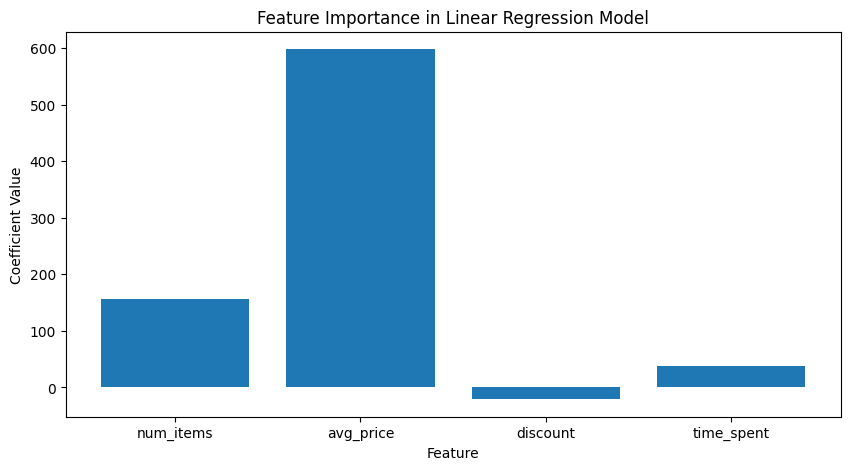

In [ ]:
import matplotlib.pyplot as plt
feature_importance=model.coef_
plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importance)),feature_importance,tick_label=["num_items",
                             "avg_price",
                            "discount",
                             "time_spent"])
plt.title("Feature Importance in Linear Regression Model")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.show()

The average check in the standardized sample is most affected by the average unit price of the product, followed by the number of products in the cart. And less so by the time spent on the website before placing the order, and even less by the discount.

In [ ]:
X.corr()

,num_items,avg_price,discount,time_spent
num_items,1.000000,0.711856,0.566820,0.763866
avg_price,0.711856,1.000000,0.690811,0.835995
discount,0.566820,0.690811,1.000000,0.729461
time_spent,0.763866,0.835995,0.729461,1.000000


We see a fairly high correlation between num_item and avg_price, discount, time_spent. Therefore, all variables are highly correlated with each other.

In [ ]:
from sklearn.linear_model import Ridge,Lasso
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2026)
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred_linreg=lin_reg.predict(X_test)
print(f"MAE:{mean_absolute_error(y_test,y_pred_linreg)}")
print(f"R2: {r2_score(y_test,y_pred_linreg)}")
ridge=Ridge()
ridge.fit(X_train,y_train)
y_pred_ridge=ridge.predict(X_test)
print(f"MAE(Ridge):{mean_absolute_error(y_test,y_pred_ridge)}")
print(f"R2(Ridge):{r2_score(y_test,y_pred_ridge)}")

MAE:156.06330940985748
R2: 0.9521145524234652
MAE(Ridge):155.6514302375919
R2(Ridge):0.9524124577205673


It is noticeable that MAE has decreased from 156 to 155 thousand. Also, slight changes in the R2 score are noticeable.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2026)
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred_linreg=lin_reg.predict(X_test)
print(f"MAE:{mean_absolute_error(y_test,y_pred_linreg)}")
print(f"R2: {r2_score(y_test,y_pred_linreg)}")
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f"MAE(Lasso):{mean_absolute_error(y_test,y_pred_lasso)}")
print(f"R2(Lasso):{r2_score(y_test,y_pred_lasso)}")

MAE:156.06330940985748
R2: 0.9521145524234652
MAE(Lasso):155.91407795117237
R2(Lasso):0.9522201405671488


Here we also see a slight decrease in MAE from 156 to 155 thousand. Also, there are noticeable slight changes in the R2 score.

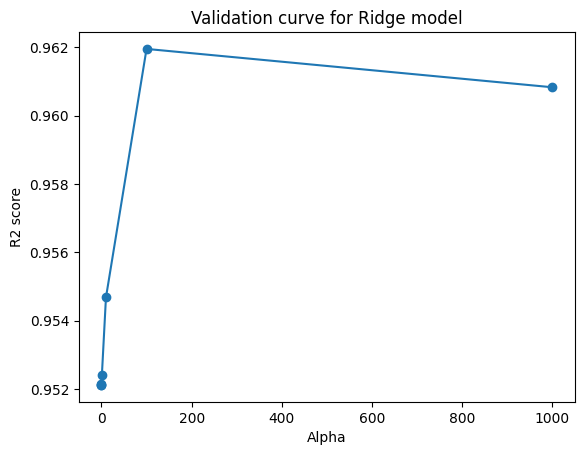

In [ ]:
possible_alpha=[0.001,0.01,0.1,1,10,100,1000]
r2_scores=[]
for alpha in possible_alpha:
  ridge=Ridge(alpha=alpha)
  ridge.fit(X_train,y_train)
  y_pred_ridgee=ridge.predict(X_test)
  r2_scores.append(r2_score(y_test,y_pred_ridgee))

plt.plot(possible_alpha,r2_scores,marker="o")
plt.xlabel("Alpha")
plt.ylabel("R2 score")
plt.title("Validation curve for Ridge model")
plt.show()

In [ ]:
print(f"r2:{r2_scores}")
print(f"Possible alpha:{possible_alpha}")

r2:[0.9521148557260457, 0.9521175849552668, 0.9521448284197787, 0.9524124577205673, 0.9546752983174378, 0.9619533950463575, 0.9608305973896566]
Possible alpha:[0.001, 0.01, 0.1, 1, 10, 100, 1000]


The optimal value is alpha=100.

In [ ]:
ridgge = Ridge(alpha=100)
ridgge.fit(X_train, y_train)
y_pred_ridgge = ridgge.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridgge)}")
print(f"R2: {r2_score(y_test, y_pred_ridgge)}")

MAE: 138.15790116766618
R2: 0.9619533950463575


We see a significant reduction in the MAE error to 138 thousand, and we see an increase in the R2 score to 96%, which is a satisfactory accurate result.

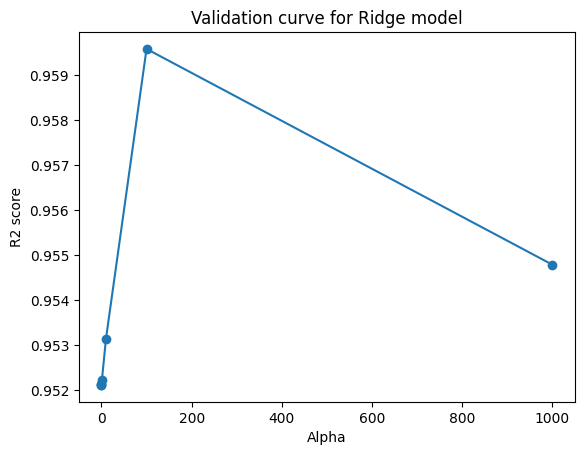

In [ ]:
possible_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
r2_scores = []
mae_scores = []
for alpha in possible_alphas:
    lassoo = Lasso(alpha=alpha)
    lassoo.fit(X_train, y_train)
    y_pred_lassoo = lassoo.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred_lassoo))


plt.plot(possible_alphas,r2_scores,marker="o")
plt.xlabel("Alpha")
plt.ylabel("R2 score")
plt.title("Validation curve for Ridge model")
plt.show()

We see the optimal alpha=100.

In [ ]:
lasso = Lasso(alpha=100)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso)}")
print(f"R2: {r2_score(y_test, y_pred_lasso)}")

MAE: 140.5711821140371
R2: 0.9595772301831436


In [ ]:
print(f"Lasso coefficients:{lasso.coef_}")

Lasso coefficients:[28.55057351  6.9183797  -0.          4.98733356]


After analyzing the coefficients of the Lasso model, we see only a third unimportant variable, which is equal to 0.